In [2]:
# Cell 1 - Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, GridSearchCV, RandomizedSearchCV,
    cross_val_score
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score, accuracy_score
)

import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/models", exist_ok=True)

In [3]:
# CELL 2 — Load HaluEval summarization feature matrix
df = pd.read_csv("../data/processed/halueval_sum_features.csv")
print("Shape:", df.shape)
print("\nLabel distribution:")
print(df["label"].value_counts())

FEATURE_COLS = [
    "response_len", "hedge_count", "rouge1", "rougeL",
    "bleu", "sem_sim", "bertscore_f1", "nli_score"
]

X = df[FEATURE_COLS].values
y = df["label"].values

print(f"\nFeature matrix: {X.shape}")
print(f"Class balance: {y.mean():.3f} (0.5 = perfect)")

Shape: (5000, 12)

Label distribution:
label
0    2500
1    2500
Name: count, dtype: int64

Feature matrix: (5000, 8)
Class balance: 0.500 (0.5 = perfect)


In [4]:
# CELL 3 — Length bias ablation test
# Carried over from QA investigation to verify this dataset is less susceptible to the same artifact
pipe_lr = Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression())])

# Test 1: response_len only
scores_len = cross_val_score(
    pipe_lr, df[["response_len"]].values, y, cv=5, scoring="f1"
)
print(f"F1 using response_len ONLY: {scores_len.mean():.4f} ± {scores_len.std():.4f}")

# Test 2: all features except response_len
no_len_cols = [f for f in FEATURE_COLS if f != "response_len"]
scores_no_len = cross_val_score(
    pipe_lr, df[no_len_cols].values, y, cv=5, scoring="f1"
)
print(f"F1 without response_len: {scores_no_len.mean():.4f} ± {scores_no_len.std():.4f}")

# Test 3: all features
scores_all = cross_val_score(
    pipe_lr, X, y, cv=5, scoring="f1"
)
print(f"F1 with all features: {scores_all.mean():.4f} ± {scores_all.std():.4f}")

F1 using response_len ONLY: 0.6881 ± 0.0193
F1 without response_len: 0.6630 ± 0.0206
F1 with all features: 0.7376 ± 0.0097


In [5]:
# CELL 4 — Train/test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} rows")
print(f"Test size: {X_test.shape[0]} rows")
print(f"\nTrain label balance: {y_train.mean():.3f}")
print(f"Test label balance: {y_test.mean():.3f}")

Train size: 4000 rows
Test size: 1000 rows

Train label balance: 0.500
Test label balance: 0.500


In [7]:
# CELL 5 — Define all 6 classifiers with pipelines
pipelines = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(probability=True, random_state=42))
    ]),
    "Decision Tree": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", DecisionTreeClassifier(random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(random_state=42))
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", XGBClassifier(
            random_state=42, eval_metric="logloss",
            verbosity=0, use_label_encoder=False
        ))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier())
    ])
}

In [8]:
# CELL 6 — Baseline evaluation: Stratified 5-fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
baseline_results = {}

print("Running 5-fold CV on untuned models...\n")
for name, pipe in pipelines.items():
    scores = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring=["accuracy", "f1", "roc_auc"],
        return_train_score=False
    )
    baseline_results[name] = {
        "Accuracy" : scores["test_accuracy"].mean(),
        "F1" : scores["test_f1"].mean(),
        "AUC" : scores["test_roc_auc"].mean(),
        "Acc Std" : scores["test_accuracy"].std(),
        "F1 Std" : scores["test_f1"].std(),
    }
    print(f"{name}: F1={baseline_results[name]['F1']:.4f} | "
          f"AUC={baseline_results[name]['AUC']:.4f} | "
          f"Acc={baseline_results[name]['Accuracy']:.4f}")

baseline_df = pd.DataFrame(baseline_results).T.sort_values("F1", ascending=False)
print("\nBaseline Results (sorted by F1):")
print(baseline_df.round(4))

Running 5-fold CV on untuned models...

Logistic Regression: F1=0.7381 | AUC=0.8167 | Acc=0.7448
SVM: F1=0.7331 | AUC=0.8198 | Acc=0.7430
Decision Tree: F1=0.6662 | AUC=0.6663 | Acc=0.6663
Random Forest: F1=0.7379 | AUC=0.8127 | Acc=0.7403
Gradient Boosting: F1=0.7329 | AUC=0.8086 | Acc=0.7332
KNN: F1=0.7054 | AUC=0.7649 | Acc=0.7067

Baseline Results (sorted by F1):
                     Accuracy      F1     AUC  Acc Std  F1 Std
Logistic Regression    0.7448  0.7381  0.8167   0.0120  0.0147
Random Forest          0.7403  0.7379  0.8127   0.0112  0.0114
SVM                    0.7430  0.7331  0.8198   0.0127  0.0175
Gradient Boosting      0.7332  0.7329  0.8086   0.0065  0.0073
KNN                    0.7067  0.7054  0.7649   0.0148  0.0123
Decision Tree          0.6662  0.6662  0.6662   0.0175  0.0174


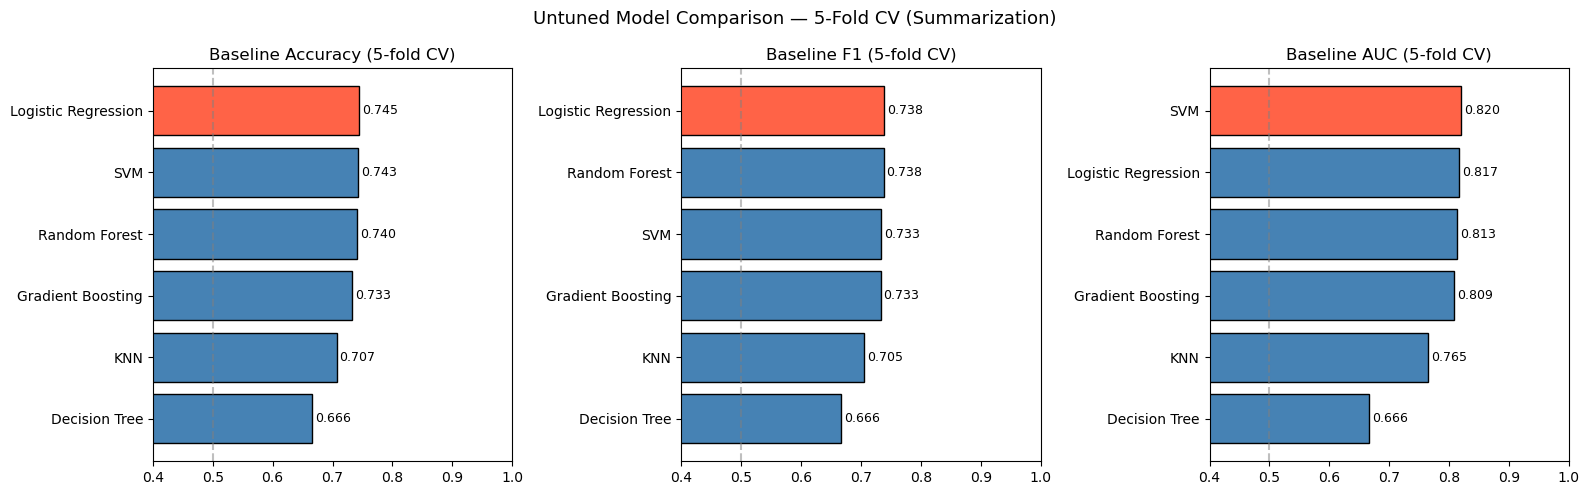

In [9]:
# CELL 7 — Visualize baseline results
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ["Accuracy", "F1", "AUC"]

for i, metric in enumerate(metrics):
    vals = baseline_df[metric].sort_values()
    colors = ["tomato" if v == vals.max() else "steelblue" for v in vals]
    axes[i].barh(vals.index, vals.values, color=colors, edgecolor="black")
    axes[i].set_title(f"Baseline {metric} (5-fold CV)")
    axes[i].set_xlim(0.4, 1.0)
    axes[i].axvline(0.5, color="gray", linestyle="--", alpha=0.5, label="Random")
    for j, v in enumerate(vals.values):
        axes[i].text(v + 0.005, j, f"{v:.3f}", va="center", fontsize=9)

plt.suptitle("Untuned Model Comparison — 5-Fold CV (Summarization)", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/figures/sum_baseline_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# CELL 8 — Hyperparameter tuning
# GridSearchCV: LR, SVM, Decision Tree, KNN
# RandomizedSearchCV: Random Forest, Gradient Boosting

# Logistic Regression
lr_search = GridSearchCV(
    pipelines["Logistic Regression"],
    {"clf__C": [0.01, 0.1, 1, 10, 100],
     "clf__penalty": ["l1", "l2"],
     "clf__solver": ["liblinear"]},
    cv=cv, scoring="f1", n_jobs=-1, verbose=0
)
lr_search.fit(X_train, y_train)
print(f"LR  best params: {lr_search.best_params_}")
print(f"LR  best CV F1: {lr_search.best_score_:.4f}\n")

# SVM 
svm_search = GridSearchCV(
    pipelines["SVM"],
    {"clf__C": [0.1, 1, 10],
     "clf__kernel": ["rbf", "linear"],
     "clf__gamma": ["scale", "auto"]},
    cv=cv, scoring="f1", n_jobs=-1, verbose=0
)
svm_search.fit(X_train, y_train)
print(f"SVM best params: {svm_search.best_params_}")
print(f"SVM best CV F1: {svm_search.best_score_:.4f}\n")

# Decision Tree
dt_search = GridSearchCV(
    pipelines["Decision Tree"],
    {"clf__max_depth": [3, 5, 10, None],
     "clf__min_samples_split": [2, 5, 10],
     "clf__criterion": ["gini", "entropy"]},
    cv=cv, scoring="f1", n_jobs=-1, verbose=0
)
dt_search.fit(X_train, y_train)
print(f"DT  best params: {dt_search.best_params_}")
print(f"DT  best CV F1: {dt_search.best_score_:.4f}\n")

# Random Forest
rf_search = RandomizedSearchCV(
    pipelines["Random Forest"],
    {"clf__n_estimators": [100, 200, 300],
     "clf__max_depth": [5, 10, 20, None],
     "clf__min_samples_split": [2, 5, 10],
     "clf__max_features": ["sqrt", "log2"]},
    n_iter=20, cv=cv, scoring="f1",
    random_state=42, n_jobs=-1, verbose=0
)
rf_search.fit(X_train, y_train)
print(f"RF  best params: {rf_search.best_params_}")
print(f"RF  best CV F1: {rf_search.best_score_:.4f}\n")

# Gradient Boosting
xgb_search = RandomizedSearchCV(
    pipelines["Gradient Boosting"],
    {"clf__n_estimators": [100, 200, 300],
     "clf__max_depth": [3, 5, 7],
     "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
     "clf__subsample": [0.7, 0.8, 1.0],
     "clf__colsample_bytree": [0.7, 0.8, 1.0]},
    n_iter=20, cv=cv, scoring="f1",
    random_state=42, n_jobs=-1, verbose=0
)
xgb_search.fit(X_train, y_train)
print(f"XGB best params: {xgb_search.best_params_}")
print(f"XGB best CV F1: {xgb_search.best_score_:.4f}\n")

# KNN 
knn_search = GridSearchCV(
    pipelines["KNN"],
    {"clf__n_neighbors": [3, 5, 7, 11, 15],
     "clf__weights": ["uniform", "distance"],
     "clf__metric": ["euclidean", "manhattan"]},
    cv=cv, scoring="f1", n_jobs=-1, verbose=0
)
knn_search.fit(X_train, y_train)
print(f"KNN best params: {knn_search.best_params_}")
print(f"KNN best CV F1: {knn_search.best_score_:.4f}")

LR  best params: {'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
LR  best CV F1: 0.7392

SVM best params: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
SVM best CV F1: 0.7357

DT  best params: {'clf__criterion': 'entropy', 'clf__max_depth': 5, 'clf__min_samples_split': 2}
DT  best CV F1: 0.7287

RF  best params: {'clf__n_estimators': 100, 'clf__min_samples_split': 10, 'clf__max_features': 'log2', 'clf__max_depth': 10}
RF  best CV F1: 0.7481

XGB best params: {'clf__subsample': 1.0, 'clf__n_estimators': 100, 'clf__max_depth': 3, 'clf__learning_rate': 0.1, 'clf__colsample_bytree': 0.8}
XGB best CV F1: 0.7453

KNN best params: {'clf__metric': 'euclidean', 'clf__n_neighbors': 15, 'clf__weights': 'distance'}
KNN best CV F1: 0.7224


In [11]:
# CELL 9 — Tuned model evaluation on held-out test set
tuned_models = {
    "Logistic Regression": lr_search.best_estimator_,
    "SVM" : svm_search.best_estimator_,
    "Decision Tree" : dt_search.best_estimator_,
    "Random Forest" : rf_search.best_estimator_,
    "Gradient Boosting" : xgb_search.best_estimator_,
    "KNN" : knn_search.best_estimator_
}

tuned_results = {}
for name, model in tuned_models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    tuned_results[name] = {
        "Accuracy" : accuracy_score(y_test, y_pred),
        "F1" : f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall" : recall_score(y_test, y_pred),
        "AUC" : roc_auc_score(y_test, y_proba)
    }

tuned_df = pd.DataFrame(tuned_results).T.sort_values("F1", ascending=False)
print("Tuned Model Results on Test Set:")
print(tuned_df.round(4))

Tuned Model Results on Test Set:
                     Accuracy      F1  Precision  Recall     AUC
Gradient Boosting       0.734  0.7275     0.7458   0.710  0.8009
Random Forest           0.730  0.7256     0.7376   0.714  0.7942
Logistic Regression     0.733  0.7227     0.7516   0.696  0.8054
SVM                     0.735  0.7219     0.7594   0.688  0.8055
KNN                     0.722  0.7214     0.7229   0.720  0.7839
Decision Tree           0.698  0.6906     0.7080   0.674  0.7581


In [12]:
# CELL 10 — Tuned vs untuned comparison
comparison = pd.DataFrame({
    "Baseline F1": baseline_df["F1"],
    "Tuned F1" : tuned_df["F1"],
}).round(4)
comparison["Improvement"] = (
    comparison["Tuned F1"] - comparison["Baseline F1"]
).round(4)
comparison = comparison.sort_values("Tuned F1", ascending=False)

print("Tuned vs Untuned F1 Comparison:")
print(comparison)

Tuned vs Untuned F1 Comparison:
                     Baseline F1  Tuned F1  Improvement
Gradient Boosting         0.7329    0.7275      -0.0054
Random Forest             0.7379    0.7256      -0.0123
Logistic Regression       0.7381    0.7227      -0.0154
SVM                       0.7331    0.7219      -0.0112
KNN                       0.7054    0.7214       0.0160
Decision Tree             0.6662    0.6906       0.0244


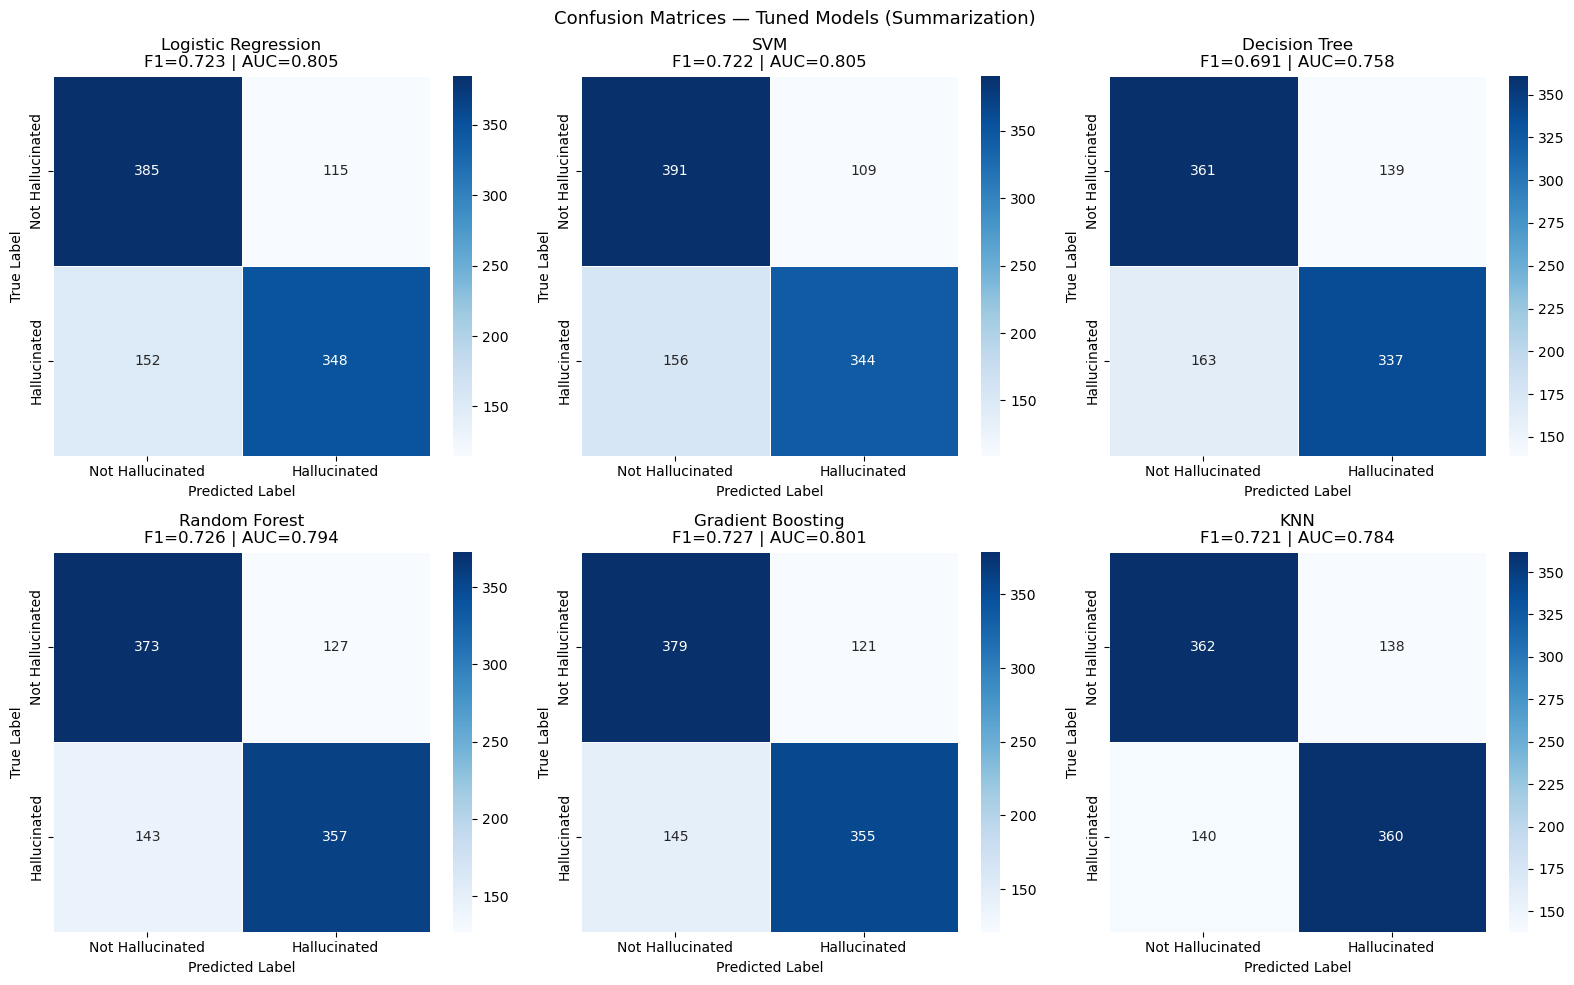

In [13]:
# CELL 11 — Confusion matrices for all tuned models
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(tuned_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", ax=axes[i],
        cmap="Blues", linewidths=0.5,
        xticklabels=["Not Hallucinated", "Hallucinated"],
        yticklabels=["Not Hallucinated", "Hallucinated"]
    )
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    axes[i].set_title(f"{name}\nF1={f1:.3f} | AUC={auc:.3f}")
    axes[i].set_ylabel("True Label")
    axes[i].set_xlabel("Predicted Label")

plt.suptitle("Confusion Matrices — Tuned Models (Summarization)", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/figures/sum_confusion_matrices.png",
            dpi=150, bbox_inches="tight")
plt.show()

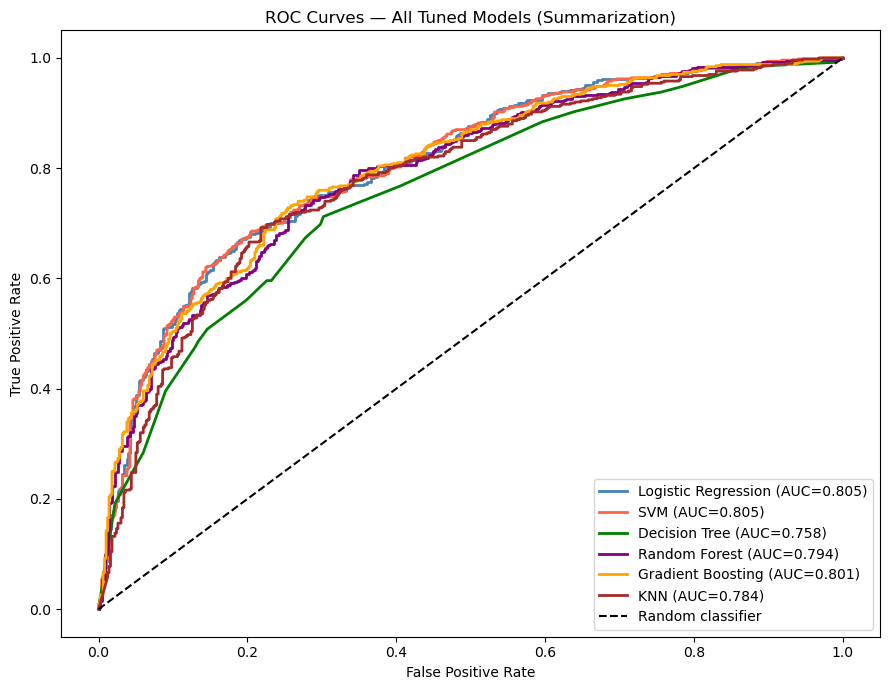

In [14]:
#  CELL 12 — ROC curves for all tuned models
fig, ax = plt.subplots(figsize=(9, 7))
colors = ["steelblue", "tomato", "green", "purple", "orange", "brown"]

for (name, model), color in zip(tuned_models.items(), colors):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, lw=2)

ax.plot([0, 1], [0, 1], "k--", label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Tuned Models (Summarization)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../outputs/figures/sum_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

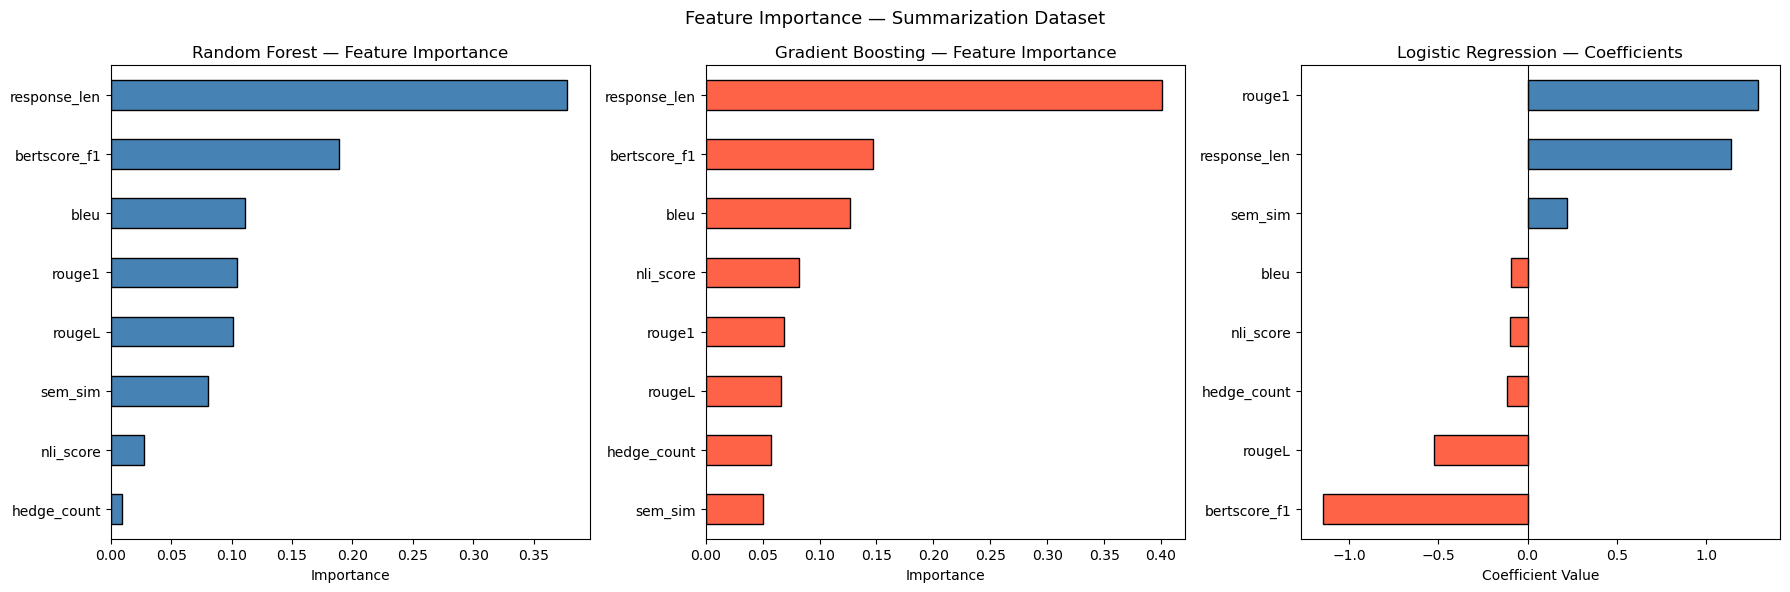

In [15]:
# CELL 13 — Feature importance analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Random Forest
rf_imp = rf_search.best_estimator_.named_steps["clf"].feature_importances_
pd.Series(rf_imp, index=FEATURE_COLS).sort_values(ascending=True).plot(
    kind="barh", ax=axes[0], color="steelblue", edgecolor="black"
)
axes[0].set_title("Random Forest — Feature Importance")
axes[0].set_xlabel("Importance")

# Gradient Boosting
xgb_imp = xgb_search.best_estimator_.named_steps["clf"].feature_importances_
pd.Series(xgb_imp, index=FEATURE_COLS).sort_values(ascending=True).plot(
    kind="barh", ax=axes[1], color="tomato", edgecolor="black"
)
axes[1].set_title("Gradient Boosting — Feature Importance")
axes[1].set_xlabel("Importance")

# Logistic Regression coefficients
lr_coef = lr_search.best_estimator_.named_steps["clf"].coef_[0]
lr_coef_df = pd.Series(lr_coef, index=FEATURE_COLS).sort_values(ascending=True)
colors_lr = ["tomato" if c < 0 else "steelblue" for c in lr_coef_df]
lr_coef_df.plot(
    kind="barh", ax=axes[2], color=colors_lr, edgecolor="black"
)
axes[2].set_title("Logistic Regression — Coefficients")
axes[2].set_xlabel("Coefficient Value")
axes[2].axvline(0, color="black", linewidth=0.8)

plt.suptitle("Feature Importance — Summarization Dataset", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/figures/sum_feature_importance.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# CELL 14 — Cross-model analysis on TruthfulQA
# Apply best tuned model to each LLM's feature matrix

responses_features = pd.read_csv(
    "../data/processed/llm_responses_features.csv"
)

best_model_name = tuned_df["F1"].idxmax()
best_model = tuned_models[best_model_name]
print(f"Best model: {best_model_name}\n")

model_cols = {
    "Mistral Small" : [f"mistral_{f}"  for f in FEATURE_COLS],
    "Llama 3.3 70B" : [f"groq_{f}"     for f in FEATURE_COLS],
    "Llama 3.1 8B" : [f"llama_hf_{f}" for f in FEATURE_COLS]
}

hal_rates = {}
for model_name, cols in model_cols.items():
    X_llm = responses_features[cols].values
    preds = best_model.predict(X_llm)
    hal_rate = preds.mean()
    hal_rates[model_name] = hal_rate
    print(f"{model_name}: {hal_rate:.1%} hallucination rate")

Best model: Gradient Boosting

Mistral Small: 99.6% hallucination rate
Llama 3.3 70B: 94.2% hallucination rate
Llama 3.1 8B: 90.1% hallucination rate


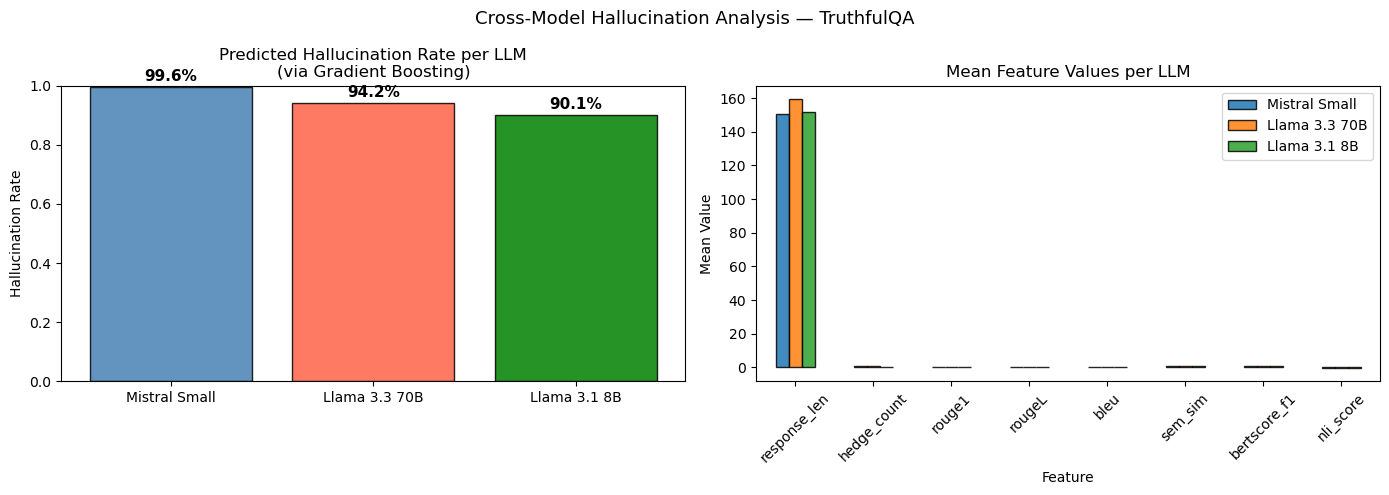

In [18]:
#  CELL 15 — Visualize cross-model hallucination rates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ["steelblue", "tomato", "green"]
bars = axes[0].bar(
    hal_rates.keys(), hal_rates.values(),
    color=colors, edgecolor="black", alpha=0.85
)
axes[0].set_ylabel("Hallucination Rate")
axes[0].set_title(
    f"Predicted Hallucination Rate per LLM\n(via {best_model_name})"
)
axes[0].set_ylim(0, 1)
for bar, val in zip(bars, hal_rates.values()):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        val + 0.02, f"{val:.1%}",
        ha="center", fontsize=11, fontweight="bold"
    )

# Feature means per model
feature_means = {
    name: responses_features[cols].mean().values
    for name, cols in model_cols.items()
}
pd.DataFrame(feature_means, index=FEATURE_COLS).plot(
    kind="bar", ax=axes[1], edgecolor="black", alpha=0.85
)
axes[1].set_title("Mean Feature Values per LLM")
axes[1].set_xlabel("Feature")
axes[1].set_ylabel("Mean Value")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(loc="upper right")

plt.suptitle("Cross-Model Hallucination Analysis — TruthfulQA", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/figures/sum_cross_model_analysis.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [19]:
# CELL 16 — Save all results
tuned_df.to_csv("../outputs/sum_tuned_model_results.csv")
comparison.to_csv("../outputs/sum_tuned_vs_baseline.csv")
pd.DataFrame(hal_rates, index=["hallucination_rate"]).to_csv(
    "../outputs/sum_cross_model_hallucination_rates.csv"
)
print("All results saved to ../outputs/")

All results saved to ../outputs/
